# Normalized Pressure SNN
## 根据原始压力帧数据训练SNN
- 仅将原始压力帧数据除以255，**进行归一化处理

验证准确率高于训练准确率，主要因为训练指标是在 Dropout 开启时统计，验证阶段关闭 Dropout

In [1]:
import os

# 必须在首次创建 CUDA 上下文前设置，确保 cuBLAS 使用确定性算法。
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
from pathlib import Path
import importlib
import sys
import numpy as np

# SpikingJelly 旧版 CuPy 后端仍会访问已被 NumPy 删除的 np.int。
# np.int 原本就是 Python int 的别名，在这里恢复该别名以保持兼容。
if "int" not in np.__dict__:
    np.int = int
import torch
import torch.nn as nn
from spikingjelly.activation_based import functional

In [2]:
def find_project_root():
    # 从 Notebook 当前工作目录逐级向上查找项目根目录。
    current = Path.cwd().resolve()

    for candidate in (current, *current.parents):
        loader_path = candidate / "src" / "data" / "loader.py"

        if loader_path.is_file():
            return candidate

    raise FileNotFoundError("无法找到 STEMNIST_Classify 项目根目录")


PROJECT_ROOT = find_project_root()

# 导入 src.data 时，需要把 src 的父目录加入模块搜索路径。
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 如果文件是在 Notebook 启动后创建的，刷新模块缓存。
importlib.invalidate_caches()

In [3]:
# True 表示优先保证同一环境中多次训练结果可重复。
REPRODUCIBLE = False    # 开启后训练速度变慢很多
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.use_deterministic_algorithms(REPRODUCIBLE)
torch.backends.cudnn.deterministic = REPRODUCIBLE
torch.backends.cudnn.benchmark = not REPRODUCIBLE
torch.set_float32_matmul_precision(
    "highest" if REPRODUCIBLE else "high"
)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = not REPRODUCIBLE
    torch.backends.cudnn.allow_tf32 = not REPRODUCIBLE

## 1. 参数定义

In [4]:
# ========================================================
# 数据参数
# ========================================================

DATA_KIND = "pressure"
BATCH_SIZE = 64
TIME_STEPS = 240
NUM_WORKERS = min(8, os.cpu_count() or 1)
PREFETCH_FACTOR = 4
LOAD_DATA_IN_MEMORY = torch.cuda.is_available()

# AMP 保留 Tensor Core 加速；严格复现时使用 Torch LIF 后端。
AMP_ENABLED = torch.cuda.is_available()
AMP_DTYPE = torch.float16
AMP_INIT_SCALE = 1024.0
SNN_BACKEND = (
    "torch"
    if REPRODUCIBLE
    else ("cupy" if torch.cuda.is_available() else "torch")
)
PROGRESS_UPDATE_INTERVAL = 20

# ========================================================
# 模型参数
# ========================================================

MODEL_NAME = "model_v4_light"
DROPOUT_RATE = 0.1
TAU = 10.0
# BN_MOMENTUM = 0.1  # model_v4不使用BN层(使用BN层会导致验证集准确率抖动)

# ========================================================
# 训练参数
# ========================================================

LEARNING_RATE = 0.005
MIN_LEARNING_RATE = 1e-5
WARMUP_EPOCHS = 5
NUM_EPOCHS = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ========================================================
# 实验名称
# ========================================================

EXPERIMENT_NAME = (
    f"[Normalized]{MODEL_NAME}"
    f"_T{TIME_STEPS}"
    f"_dropout_{DROPOUT_RATE}"
    f"_batchsize_{BATCH_SIZE}"
    f"_lr_{LEARNING_RATE}"
    f"_tau_{TAU}"
    # f"_bnmom_{BN_MOMENTUM}"
    f"_seed_{SEED}"
    f"_det_{int(REPRODUCIBLE)}"
)

# ========================================================
# 输出路径
# ========================================================

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
EXPERIMENT_DIR = OUTPUT_ROOT / DATA_KIND / EXPERIMENT_NAME

BEST_MODEL_PATH = EXPERIMENT_DIR / "best_model.pt"
HISTORY_PLOT_PATH = EXPERIMENT_DIR / "training_history.png"
HISTORY_CSV_PATH = EXPERIMENT_DIR / "training_history.csv"

CHECKPOINT_METADATA = {
    "data_kind": DATA_KIND,
    "model_name": MODEL_NAME,
    "time_steps": TIME_STEPS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "reproducible": REPRODUCIBLE,
    "backend": SNN_BACKEND,
    "amp_enabled": AMP_ENABLED,
    "amp_dtype": str(AMP_DTYPE),
    "amp_init_scale": AMP_INIT_SCALE,
}

EXPERIMENT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("数据类型：", DATA_KIND)
print("严格复现：", REPRODUCIBLE)
print("随机种子：", SEED)
print("实验目录：", EXPERIMENT_DIR)
print("模型路径：", BEST_MODEL_PATH)
print("历史记录图片路径：", HISTORY_PLOT_PATH)
print("历史记录CSV路径：", HISTORY_CSV_PATH)

数据类型： pressure
严格复现： False
随机种子： 42
实验目录： /root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0
模型路径： /root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/best_model.pt
历史记录图片路径： /root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/training_history.png
历史记录CSV路径： /root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/training_history.csv


## 2. 数据

In [5]:
from src.data.transform import build_pressure_transform
from src.data.loader import LoaderConfig, create_loaders

In [6]:
# 计算训练集数据缩放后的均值和标准差
def compute_pressure_train_stats(
    data_path,
    chunk_size=64,
):
    """只使用训练集计算缩放到 [0, 1] 后的全局 mean 和 std。"""

    pressure_data = np.load(
        data_path,
        mmap_mode="r",
        allow_pickle=False,
    )

    if pressure_data.ndim != 4:
        raise ValueError(
            "pressure.npy 应为 [N,T,H,W] 四维数组，"
            f"实际形状为 {pressure_data.shape}"
        )

    value_sum = 0.0
    squared_value_sum = 0.0
    value_count = 0

    # 分块统计，避免一次性将完整训练集转换成 float64。
    for start in range(0, len(pressure_data), chunk_size):
        end = min(start + chunk_size, len(pressure_data))

        chunk = np.asarray(
            pressure_data[start:end],
            dtype=np.float64,
        )

        # 与 PressureToTensor 保持一致：先除以 255。
        chunk /= 255.0

        value_sum += chunk.sum(dtype=np.float64)
        squared_value_sum += np.square(chunk).sum(
            dtype=np.float64
        )
        value_count += chunk.size

    if value_count == 0:
        raise RuntimeError("压力训练集中没有数据。")

    mean = value_sum / value_count
    variance = (
        squared_value_sum / value_count
        - mean**2
    )
    variance = max(variance, 0.0)
    std = float(np.sqrt(variance))

    if std <= 0.0:
        raise RuntimeError("训练集标准差必须大于 0。")

    return float(mean), std


# ========================================================
# 只使用训练集计算统计量
# ========================================================

TRAIN_PRESSURE_PATH = (
    PROJECT_ROOT
    / "data"
    / "pressure"
    / "train"
    / "pressure.npy"
)

PRESSURE_MEAN, PRESSURE_STD = compute_pressure_train_stats(
    TRAIN_PRESSURE_PATH,
)

print(f"训练集 mean：{PRESSURE_MEAN:.10f}")
print(f"训练集 std： {PRESSURE_STD:.10f}")

训练集 mean：0.3181109177
训练集 std： 0.0112653181


In [7]:
# 压力数据转换为 float32，并从 [0, 255] 缩放到 [0, 1]，再进行归一化处理。
pressure_transform = build_pressure_transform(
    mean=PRESSURE_MEAN,
    std=PRESSURE_STD,
)

config = LoaderConfig(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    seed=SEED,
    prefetch_factor=PREFETCH_FACTOR,
    in_memory=LOAD_DATA_IN_MEMORY,
)

pressure_loaders = create_loaders(
    data_root=PROJECT_ROOT / "data",
    data_kind=DATA_KIND,
    train_transform=pressure_transform,
    eval_transform=pressure_transform,
    config=config,
)
train_loader = pressure_loaders["train"]
val_loader = pressure_loaders["val"]
test_loader = pressure_loaders["test"]

In [8]:
print(f"Train loader length: {len(train_loader)}")
print(f"Validation loader length: {len(val_loader)}")
print(f"Test loader length: {len(test_loader)}")

Train loader length: 85
Validation loader length: 19
Test loader length: 19


## 3. 模型

In [9]:
# from src.models.model_v2_with_lif import ConvSNN
# model = ConvSNN(
#     num_classes=35,
#     dropout=DROPOUT_RATE,
#     tau=TAU,
#     logit_scale=1.0,
#     bn_momentum=BN_MOMENTUM,
#     backend=SNN_BACKEND,
# ).to(DEVICE)

# model.parameter_count()

In [10]:
from src.models.model_v4_light import ConvSNN
model = ConvSNN(
    num_classes=35,
    dropout=DROPOUT_RATE,
    tau=TAU,
    logit_scale=1.0,
    temporal_bins=4,
    backend=SNN_BACKEND,
).to(DEVICE)

model.parameter_count()

19443

## 4. 损失优化

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=MIN_LEARNING_RATE,
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        warmup_scheduler,
        cosine_scheduler,
    ],
    milestones=[
        WARMUP_EPOCHS,
    ],
)

## 5. 训练

In [12]:
from src.function_utils import train_epoch, validate_epoch, train_model

In [13]:
history = train_model(model, 
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            num_epochs=NUM_EPOCHS,
            save_path=BEST_MODEL_PATH,
            scheduler=scheduler,
            amp_enabled=AMP_ENABLED,
            amp_dtype=AMP_DTYPE,
            amp_init_scale=AMP_INIT_SCALE,
            progress_update_interval=PROGRESS_UPDATE_INTERVAL,
            checkpoint_metadata=CHECKPOINT_METADATA,
)

Train Epoch 1:   0%|          | 0/85 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/19 [00:00<?, ?it/s]

Validation firing rates | lif1=0.034338 | lif2=0.021403 | output=0.039002

Epoch 001/100 | Train loss: 3.5546 | Train accuracy: 0.0289 | Val loss: 3.5514 | Val accuracy: 0.0684 | LR: 0.0005 | Train: 354.6 samples/s | GPU peak: 3.84 GiB
✓ 保存最佳模型：/root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/best_model.pt
  epoch=1, val_accuracy=0.0684


Train Epoch 2:   0%|          | 0/85 [00:00<?, ?it/s]

Val Epoch 2:   0%|          | 0/19 [00:00<?, ?it/s]

...

Val Epoch 99:   0%|          | 0/19 [00:00<?, ?it/s]

Validation firing rates | lif1=0.136439 | lif2=0.082682 | output=0.070457

Epoch 099/100 | Train loss: 0.2834 | Train accuracy: 0.9111 | Val loss: 0.2645 | Val accuracy: 0.9342 | LR: 1.5455e-05 | Train: 2452.0 samples/s | GPU peak: 1.24 GiB


Train Epoch 100:   0%|          | 0/85 [00:00<?, ?it/s]

Val Epoch 100:   0%|          | 0/19 [00:00<?, ?it/s]

Validation firing rates | lif1=0.136437 | lif2=0.082650 | output=0.070468

Epoch 100/100 | Train loss: 0.2844 | Train accuracy: 0.9078 | Val loss: 0.2654 | Val accuracy: 0.9333 | LR: 1.13641e-05 | Train: 2519.5 samples/s | GPU peak: 1.24 GiB

训练完成
最佳 epoch：79
最佳验证集准确率：0.9403
最佳模型路径：/root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/best_model.pt


## 6. 结果可视化与数据保存

In [14]:
from src.function_utils import plot_training_history

训练曲线已保存：/root/autodl-tmp/STEMNIST_Classify/outputs/pressure/[Normalized]model_v4_light_T240_dropout_0.1_batchsize_64_lr_0.005_tau_10.0_seed_42_det_0/training_history.png


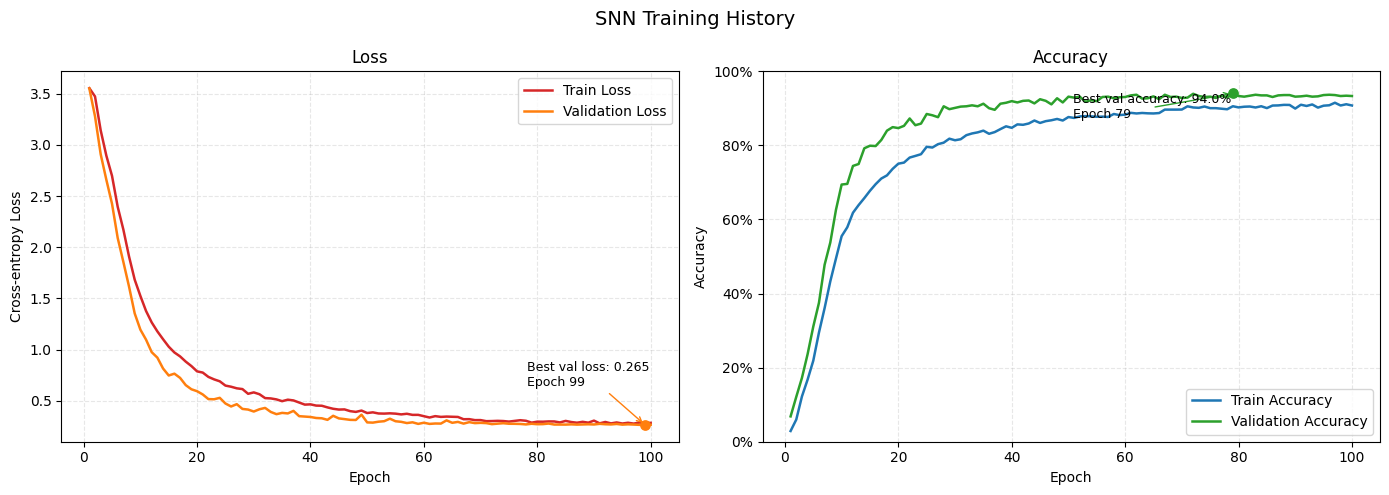

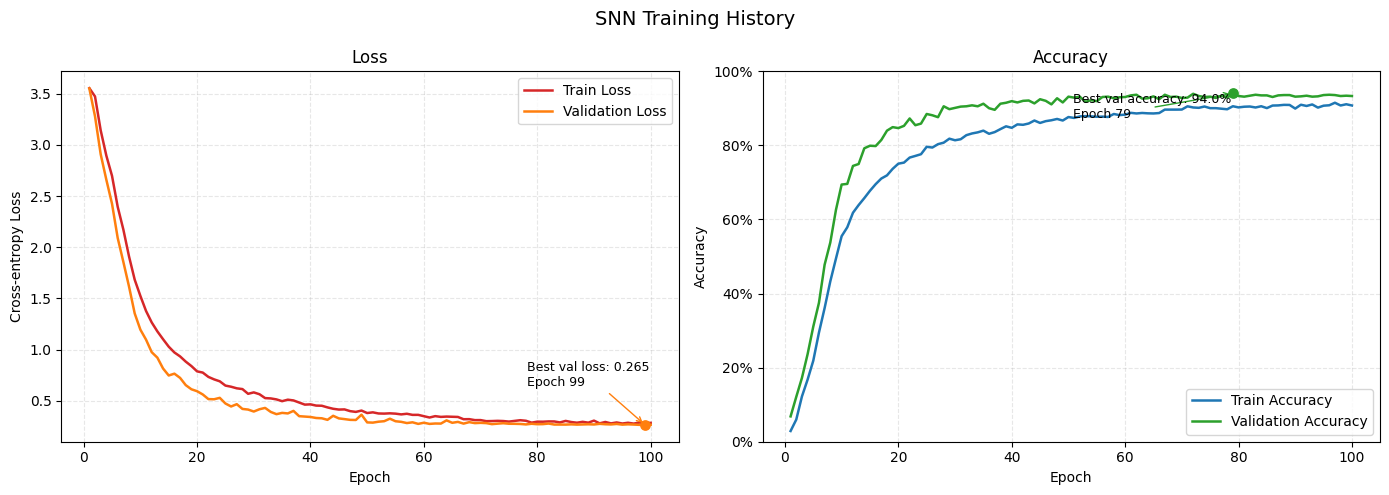

In [15]:
plot_training_history(
    history,
    save_path=HISTORY_PLOT_PATH,
)

In [16]:
# 保存history为csv文件
import pandas as pd
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_CSV_PATH, index=False)

## 7. 测试集准确率

In [17]:
# 测试集准确率
test_result = validate_epoch(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test accuracy: {test_result['accuracy']:.4f}")

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Test accuracy: 0.9351
